# Reuters Corpus — Clustering Evaluation

In [18]:
import sys, os
sys.path.insert(0, os.path.join('..', '..', 'src'))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter
from load_data import load_data

## 1. Exploratory Data Analysis

In [19]:
df = load_data()
print(f"Documents: {len(df)}")
print(f"Columns: {list(df.columns)}")
df.head()

NLTK resources:
	- stopwords ok
	- reuters downloading... ok
	- punkt_tab ok
Documents: 10788
Columns: ['ids', 'categories', 'text']


,ids,categories,text
0,test/14826,[trade],ASIAN EXPORTERS FEAR DAMAGE FROM U.S.-JAPAN RI...
1,test/14828,[grain],CHINA DAILY SAYS VERMIN EAT 7-12 PCT GRAIN STO...
2,test/14829,"[crude, nat-gas]",JAPAN TO REVISE LONG-TERM ENERGY DEMAND DOWNWA...
3,test/14832,"[corn, grain, rice, rubber, sugar, tin, trade]",THAI TRADE DEFICIT WIDENS IN FIRST QUARTER\n ...
4,test/14833,"[palm-oil, veg-oil]",INDONESIA SEES CPO PRICE RISING SHARPLY\n Ind...


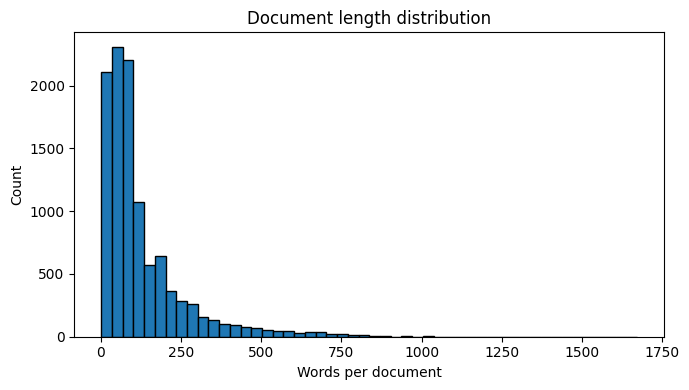

count    10788.000000
mean       127.762792
std        136.060590
min          2.000000
25%         44.000000
50%         84.000000
75%        158.000000
max       1672.000000
Name: text, dtype: float64


In [20]:
doc_lengths = df['text'].str.split().str.len()

plt.figure(figsize=(7, 4))
plt.hist(doc_lengths, bins=50, edgecolor='black')
plt.xlabel('Words per document')
plt.ylabel('Count')
plt.title('Document length distribution')
plt.tight_layout()
plt.show()

print(doc_lengths.describe())

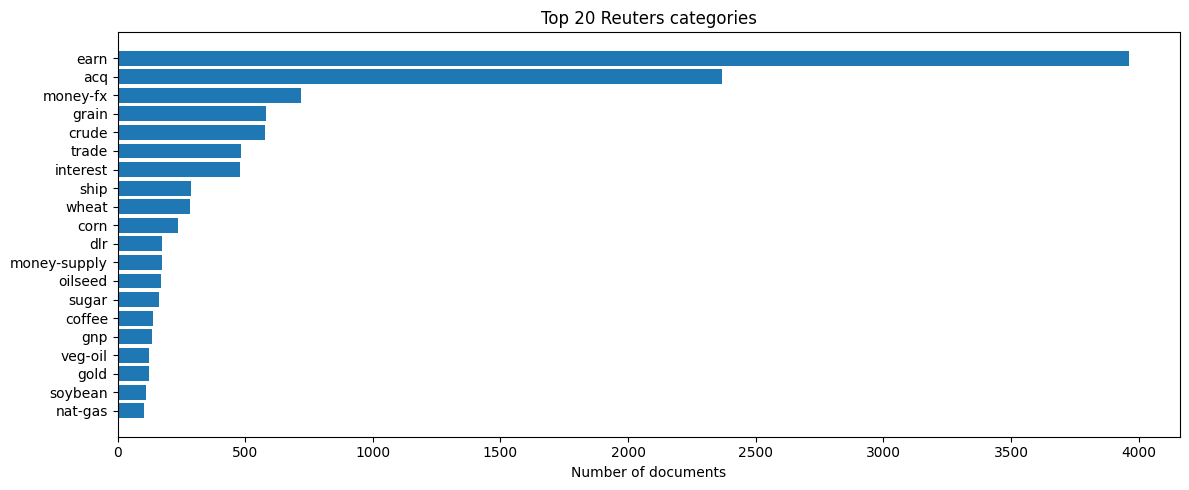

Total unique categories: 90
Categories per document — mean: 1.24, max: 15


In [21]:
all_cats = [c for cats in df['categories'] for c in cats]
cat_counts = Counter(all_cats).most_common(20)

labels, counts = zip(*cat_counts)
plt.figure(figsize=(12, 5))
plt.barh(labels[::-1], counts[::-1])
plt.xlabel('Number of documents')
plt.title('Top 20 Reuters categories')
plt.tight_layout()
plt.show()

print(f"Total unique categories: {len(set(all_cats))}")
cats_per_doc = [len(cats) for cats in df['categories']]
print(f"Categories per document — mean: {np.mean(cats_per_doc):.2f}, max: {max(cats_per_doc)}")

## 2. WCSS Tuning (Elbow Method)

In [22]:
ks = list(range(1, 11))

wcss_tfidf_custom = [6621.30, 6560.36, 6546.90, 6517.24, 6518.21, 6490.48, 6483.49, 6478.66, 6467.10, 6461.94]
wcss_tfidf_sklearn = [8278.52, 7943.71, 7877.60, 7814.06, 7768.40, 7671.49, 7636.89, 7611.27, 7583.46, 7548.68]
wcss_word2vec = [4148.12, 2454.96, 1798.69, 1547.03, 1469.78, 1352.85, 1228.40, 1197.45, 1143.26, 1108.41]

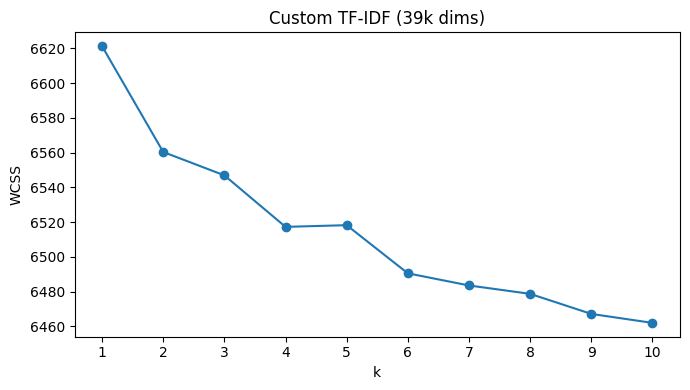

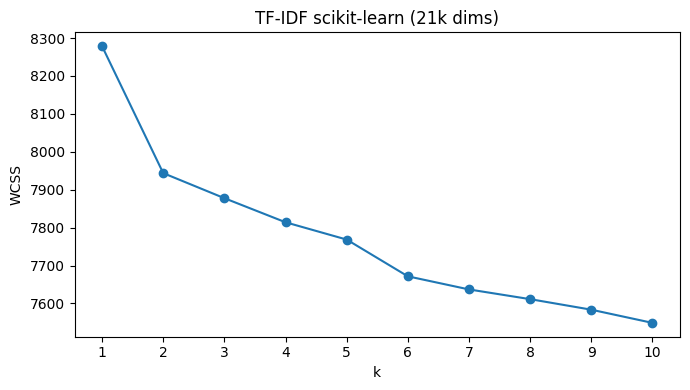

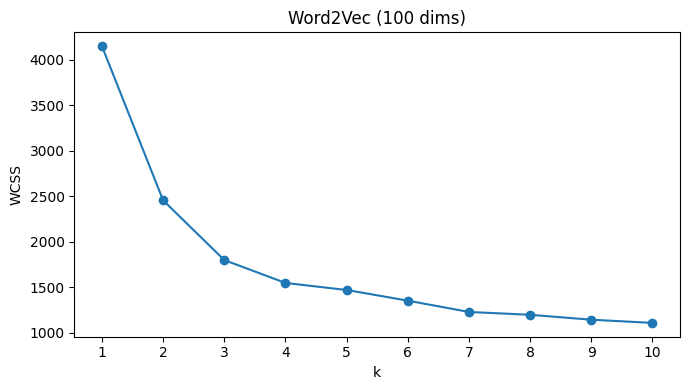

In [23]:
# Plot each WCSS curve in a separate plot
plot_configs = [
    (wcss_tfidf_custom, 'Custom TF-IDF (39k dims)'),
    (wcss_tfidf_sklearn, 'TF-IDF scikit-learn (21k dims)'),
    (wcss_word2vec, 'Word2Vec (100 dims)'),
]

for wcss, title in plot_configs:
    plt.figure(figsize=(7, 4))
    plt.plot(ks, wcss, 'o-')
    plt.xlabel('k')
    plt.ylabel('WCSS')
    plt.title(title)
    plt.xticks(ks)
    plt.tight_layout()
    plt.show()

TF-IDF curves are nearly flat (~2-3% total variation) — KMeans with cosine distance struggles with high-dimensional sparse vectors.  
Word2Vec shows a clear elbow at **k=4-5**.

## 3. Evaluation Results (Test Set, k=6)

In [24]:
eval_data = {
    'Experiment': [
        'Baseline',       'Baseline',       'Baseline',
        'SVD preproc',    'SVD preproc',    'SVD preproc',
    ],
    'Embedding': [
        'Custom TF-IDF',    'TF-IDF sklearn', 'Word2Vec',
        'Custom TF-IDF',    'TF-IDF sklearn', 'Word2Vec',
    ],
    'Dims': [39204, 21519, 100, 300, 300, 100],
    'WCSS':           [907.04, 1897.93, 327.81, 284.70, 656.30, 322.24],
    'Silhouette':     [-0.0652, 0.0202, 0.2986, 0.0396, 0.0427, 0.3106],
    'Davies-Bouldin': [8.0253, 6.5651, 1.3788, 3.7895, 3.8062, 1.3923],
}

eval_df = pd.DataFrame(eval_data)
eval_df

,Experiment,Embedding,Dims,WCSS,Silhouette,Davies-Bouldin
0,Baseline,Custom TF-IDF,39204,907.04,-0.0652,8.0253
1,Baseline,TF-IDF sklearn,21519,1897.93,0.0202,6.5651
2,Baseline,Word2Vec,100,327.81,0.2986,1.3788
3,SVD preproc,Custom TF-IDF,300,284.70,0.0396,3.7895
4,SVD preproc,TF-IDF sklearn,300,656.30,0.0427,3.8062
5,SVD preproc,Word2Vec,100,322.24,0.3106,1.3923


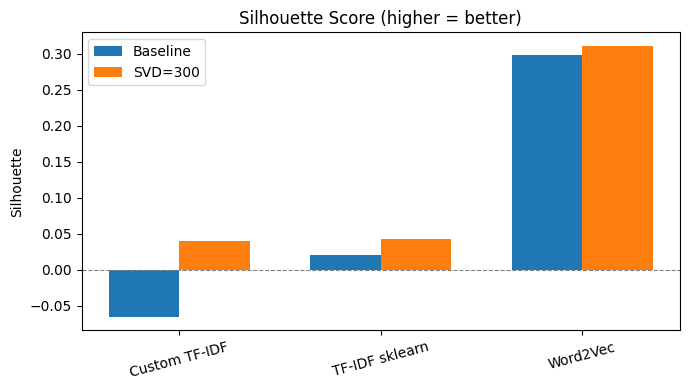

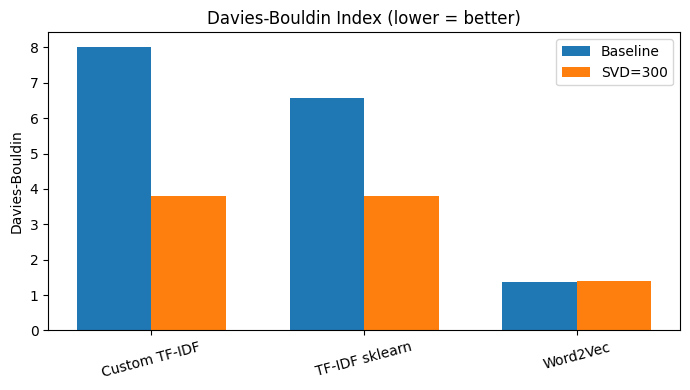

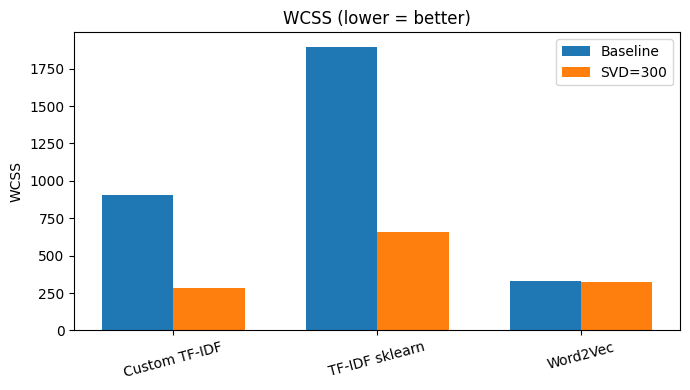

In [25]:
embeddings = ['Custom TF-IDF', 'TF-IDF sklearn', 'Word2Vec']
baseline = eval_df[eval_df['Experiment'] == 'Baseline']
svd = eval_df[eval_df['Experiment'] == 'SVD preproc']
x = np.arange(len(embeddings))
w = 0.35

# Silhouette Plot
plt.figure(figsize=(7, 4))
plt.bar(x - w/2, baseline['Silhouette'].values, w, label='Baseline')
plt.bar(x + w/2, svd['Silhouette'].values, w, label='SVD=300')
plt.xticks(x, embeddings, rotation=15)
plt.ylabel('Silhouette')
plt.title('Silhouette Score (higher = better)')
plt.axhline(y=0, color='gray', linestyle='--', linewidth=0.8)
plt.legend()
plt.tight_layout()
plt.show()

# Davies-Bouldin Plot
plt.figure(figsize=(7, 4))
plt.bar(x - w/2, baseline['Davies-Bouldin'].values, w, label='Baseline')
plt.bar(x + w/2, svd['Davies-Bouldin'].values, w, label='SVD=300')
plt.xticks(x, embeddings, rotation=15)
plt.ylabel('Davies-Bouldin')
plt.title('Davies-Bouldin Index (lower = better)')
plt.legend()
plt.tight_layout()
plt.show()

# WCSS Plot
plt.figure(figsize=(7, 4))
plt.bar(x - w/2, baseline['WCSS'].values, w, label='Baseline')
plt.bar(x + w/2, svd['WCSS'].values, w, label='SVD=300')
plt.xticks(x, embeddings, rotation=15)
plt.ylabel('WCSS')
plt.title('WCSS (lower = better)')
plt.legend()
plt.tight_layout()
plt.show()

## 5. Cluster Visualization (t-SNE)

In [26]:
import joblib
from sklearn.manifold import TSNE

DATA_DIR = os.path.join('..', '..', 'data')

models = {
    'Custom TF-IDF (SVD=300)': {
        'model': os.path.join(DATA_DIR, 'models', 'kmeans_v8.joblib'),
        'test':  os.path.join(DATA_DIR, 'vectors', 'tfidf-custom-svd300', 'test.csv'),
    },
    'TF-IDF sklearn (SVD=300)': {
        'model': os.path.join(DATA_DIR, 'models', 'kmeans_v9.joblib'),
        'test':  os.path.join(DATA_DIR, 'vectors', 'tfidf-scikit-learn-svd300', 'test.csv'),
    },
    'Word2Vec': {
        'model': os.path.join(DATA_DIR, 'models', 'kmeans_v7.joblib'),
        'test':  os.path.join(DATA_DIR, 'vectors', 'word2vec', 'test.csv'),
    },
}

/home/cesare/miniforge3/envs/nlp/lib/python3.10/site-packages/nltk/cluster/util.py:130: RuntimeWarning: invalid value encountered in scalar divide
  return 1 - (numpy.dot(u, v) / (sqrt(numpy.dot(u, u)) * sqrt(numpy.dot(v, v))))


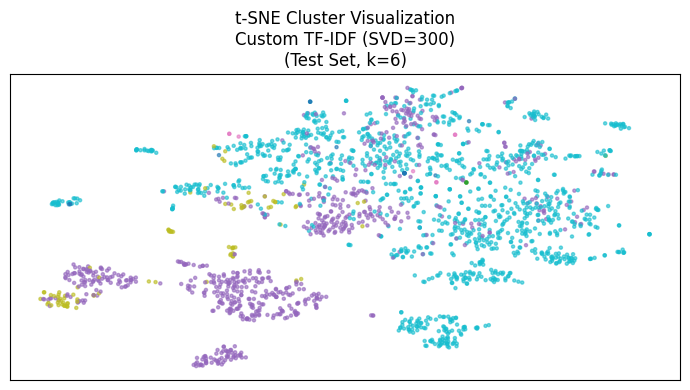

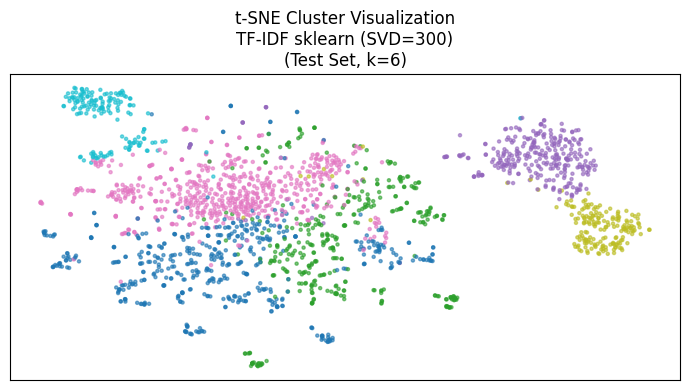

/home/cesare/miniforge3/envs/nlp/lib/python3.10/site-packages/nltk/cluster/util.py:130: RuntimeWarning: invalid value encountered in scalar divide
  return 1 - (numpy.dot(u, v) / (sqrt(numpy.dot(u, u)) * sqrt(numpy.dot(v, v))))


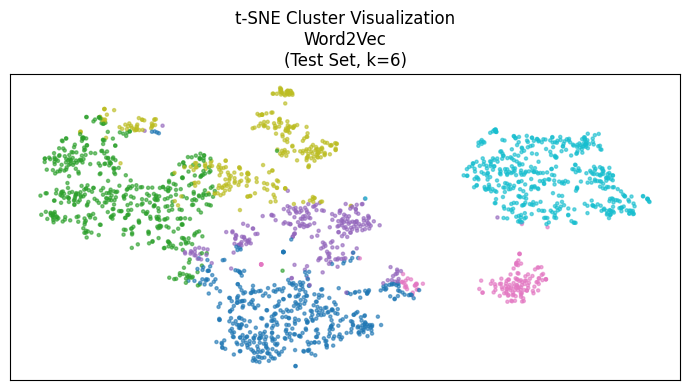

In [27]:
for name, paths in models.items():
    km = joblib.load(paths['model'])
    X = np.loadtxt(paths['test'], delimiter=',', ndmin=2, dtype=np.float64)
    labels = km.predict(X)

    tsne = TSNE(n_components=2, random_state=42, perplexity=30, max_iter=1000)
    X_2d = tsne.fit_transform(X)

    plt.figure(figsize=(7, 4))
    scatter = plt.scatter(X_2d[:, 0], X_2d[:, 1], c=labels, cmap='tab10', s=5, alpha=0.6)
    plt.title(f't-SNE Cluster Visualization\n{name}\n(Test Set, k=6)')
    plt.xticks([])
    plt.yticks([])
    plt.tight_layout()
    plt.show()

/home/cesare/miniforge3/envs/nlp/lib/python3.10/site-packages/nltk/cluster/util.py:130: RuntimeWarning: invalid value encountered in scalar divide
  return 1 - (numpy.dot(u, v) / (sqrt(numpy.dot(u, u)) * sqrt(numpy.dot(v, v))))


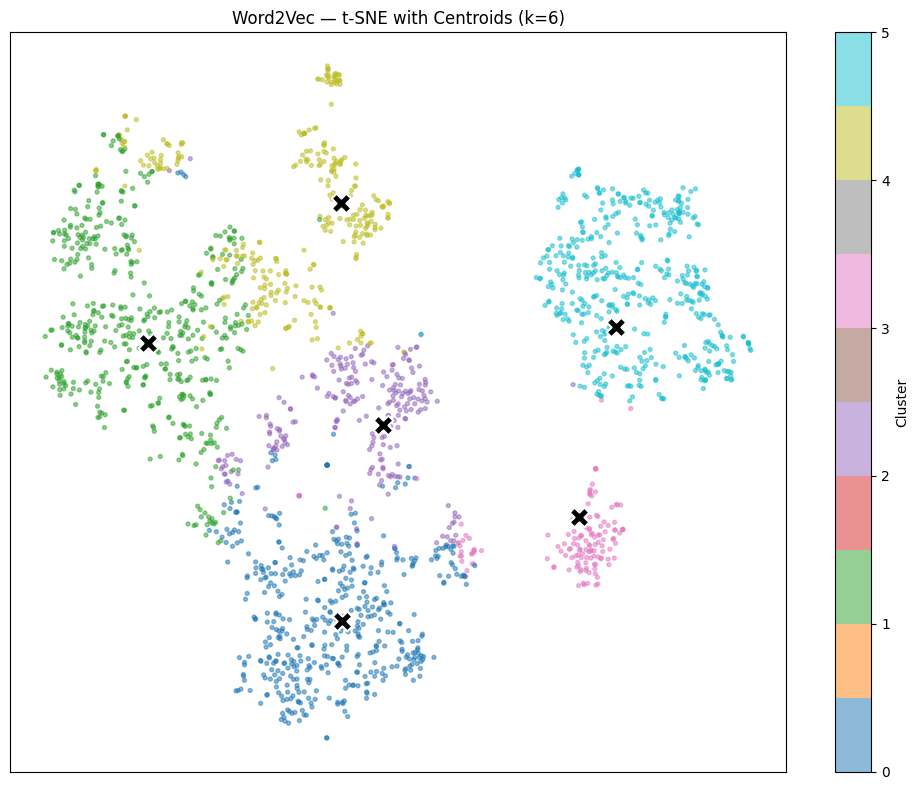

	Cluster 0: 486 documents (22.5%)
	Cluster 1: 503 documents (23.3%)
	Cluster 2: 241 documents (11.2%)
	Cluster 3: 140 documents (6.5%)
	Cluster 4: 314 documents (14.6%)
	Cluster 5: 473 documents (21.9%)


In [28]:
km = joblib.load(models['Word2Vec']['model'])
X = np.loadtxt(models['Word2Vec']['test'], delimiter=',', ndmin=2, dtype=np.float64)
labels = km.predict(X)
centers = km.cluster_centers_

X_all = np.vstack([X, centers])
tsne = TSNE(n_components=2, random_state=42, perplexity=30, max_iter=1000)
X_all_2d = tsne.fit_transform(X_all)

X_2d = X_all_2d[:len(X)]
C_2d = X_all_2d[len(X):]

plt.figure(figsize=(10, 8))
scatter = plt.scatter(X_2d[:, 0], X_2d[:, 1], c=labels, cmap='tab10', s=8, alpha=0.5)
plt.scatter(C_2d[:, 0], C_2d[:, 1], c='black', marker='X', s=200, edgecolors='white', linewidths=1.5, zorder=5)

plt.colorbar(scatter, label='Cluster')
plt.title('Word2Vec — t-SNE with Centroids (k=6)')
plt.xticks([])
plt.yticks([])
plt.tight_layout()
plt.show()

for i in range(km.n_clusters):
    count = (labels == i).sum()
    print(f"\tCluster {i}: {count} documents ({100*count/len(labels):.1f}%)")

## 4. Summary

**Best model: Word2Vec (k=6, repeats=5)**

| Metric | Value |
|---|---|
| Silhouette | 0.3106 |
| Davies-Bouldin | 1.3923 |
| WCSS | 322.24 |

**Key findings:**
- Word2Vec consistently outperforms TF-IDF across all metrics
- Raw TF-IDF (39k/21k dims) produces near-random clusters (Silhouette ≈ 0)
- SVD=300 preprocessing improves TF-IDF (Silhouette from negative to ~0.04, DB halved) but still far behind Word2Vec
- Word2Vec dense 100-dim vectors are well-suited for cosine-based KMeans without dimensionality reduction